# 🌸 Task 1: Iris Flower Classification

**Objective:** Train a machine learning model to classify Iris flower species (*setosa*, *versicolor*, *virginica*) based on sepal and petal measurements.

**Tools:** Python · Scikit-learn · Pandas · Matplotlib · Seaborn

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## 2. Load and Explore the Dataset

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv')

# Drop the Id column — it's just a row index
df.drop(columns=['Id'], inplace=True)

print('Shape:', df.shape)
df.head(10)

Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Class Distribution ===')
print(df['Species'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Missing Values ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

=== Class Distribution ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [4]:
df.describe().round(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 3. Exploratory Data Analysis (EDA)

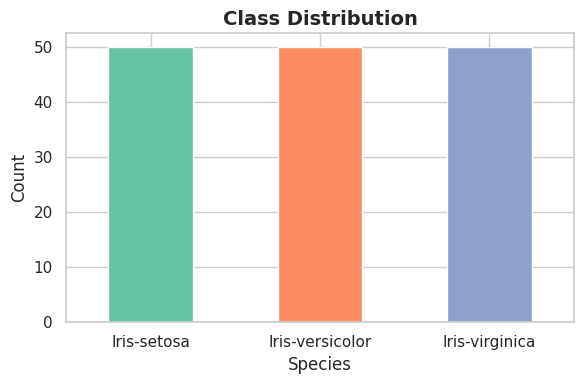

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
df['Species'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 3), edgecolor='white')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

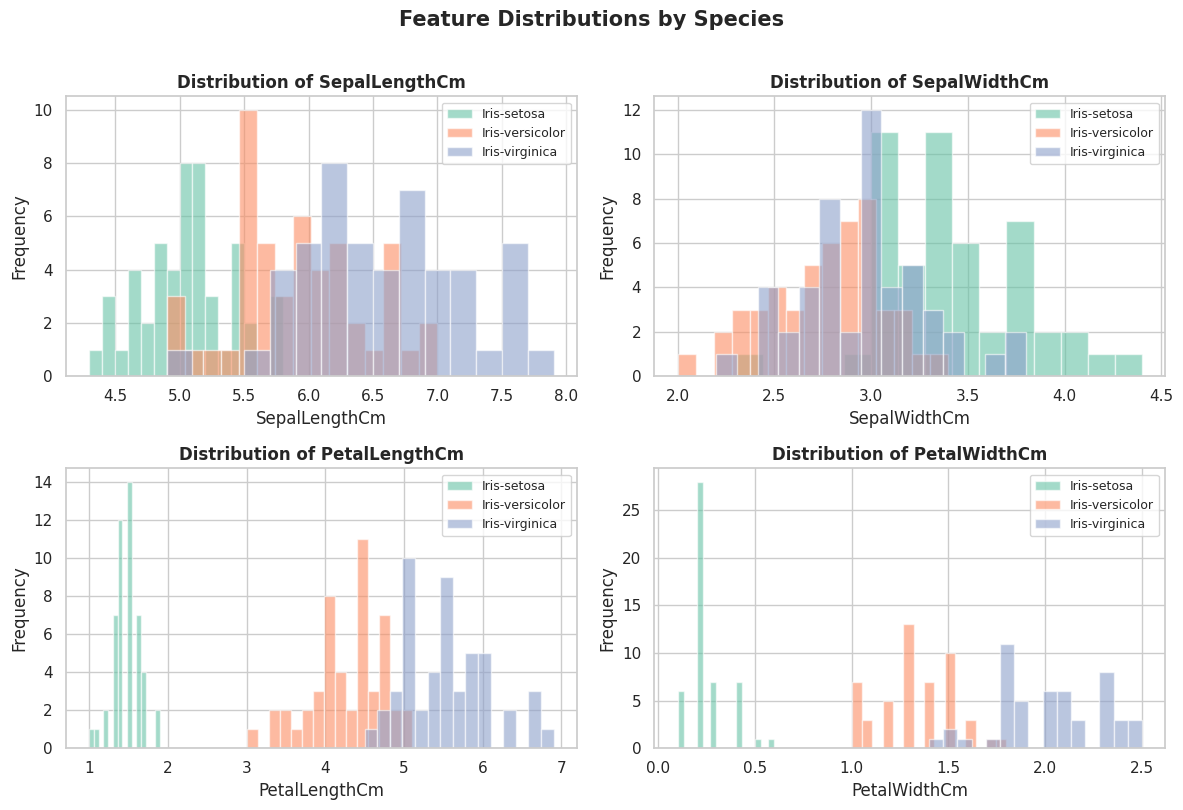

In [6]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species in df['Species'].unique():
        subset = df[df['Species'] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species, edgecolor='white')
    axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

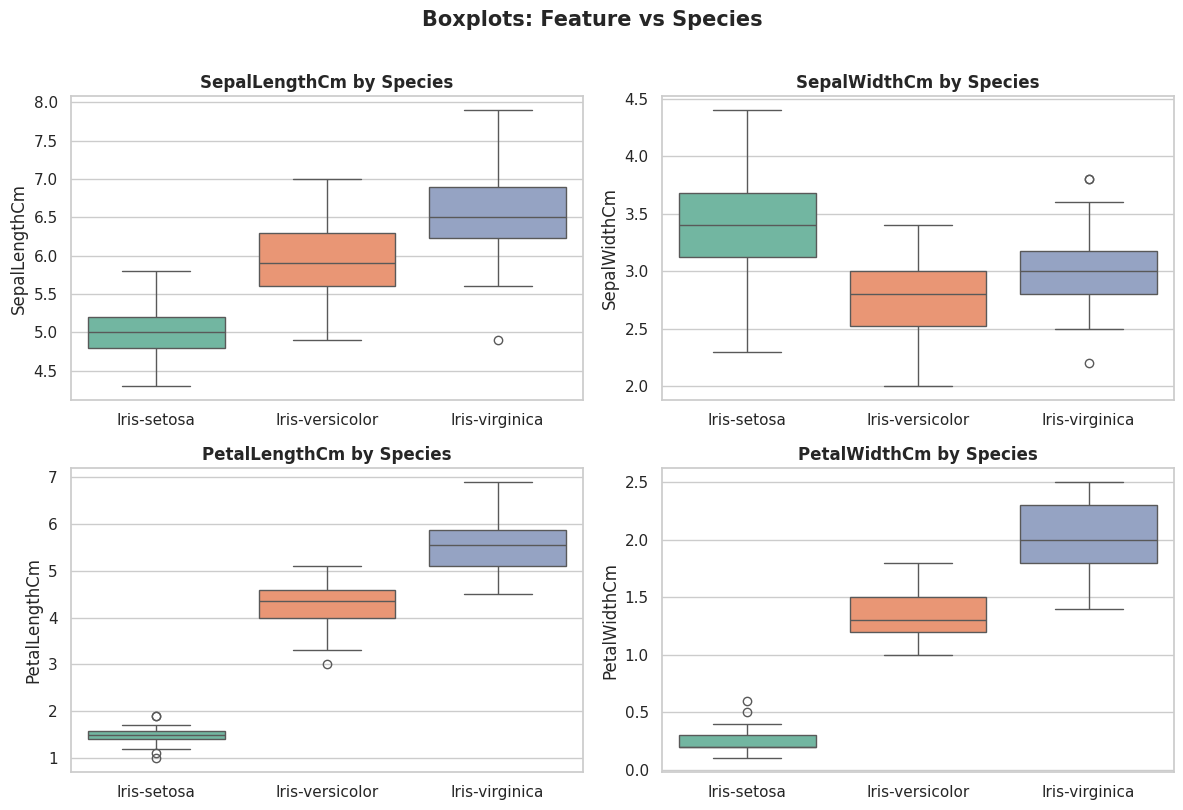

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Species', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} by Species', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots: Feature vs Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

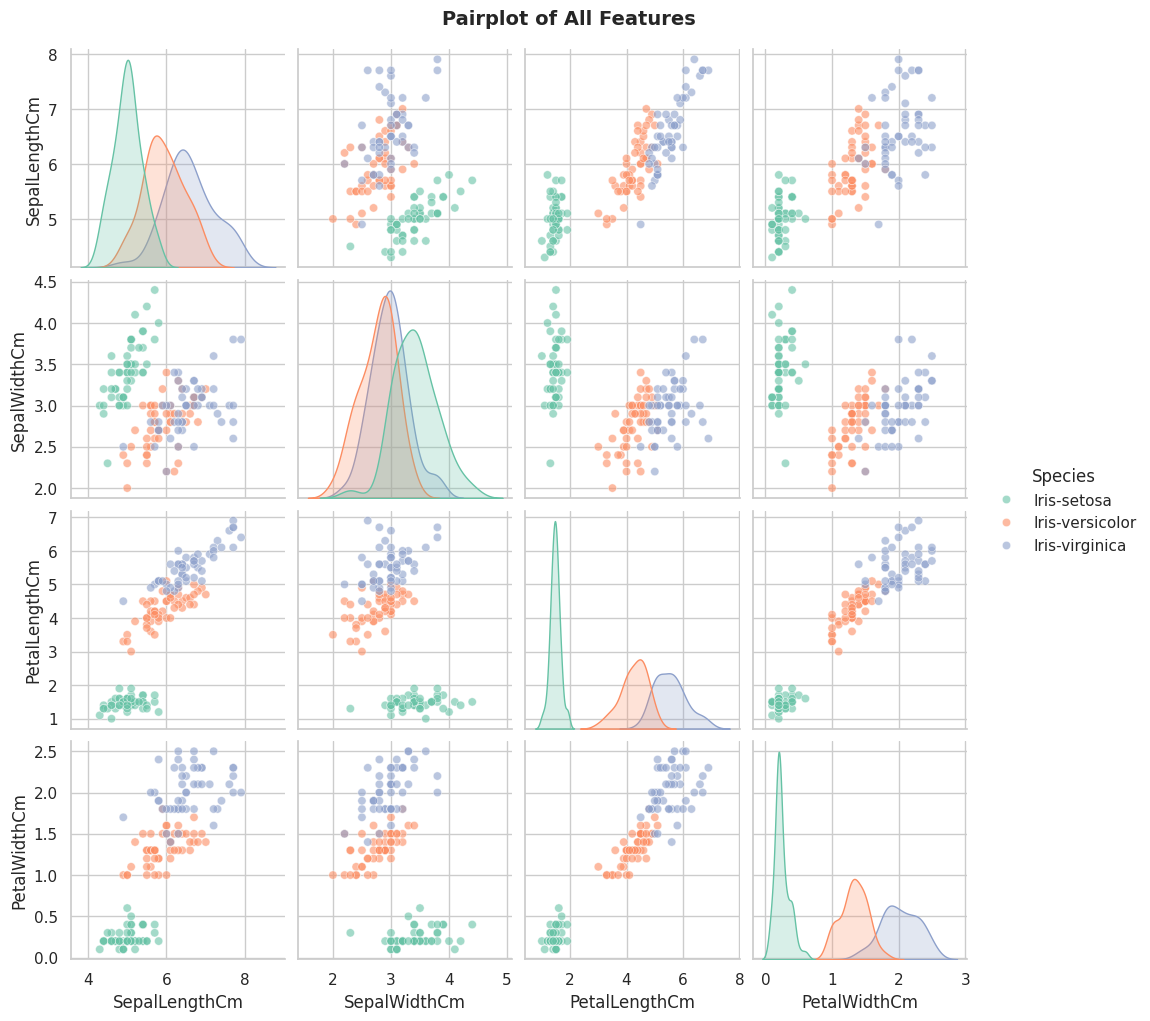

In [8]:
sns.pairplot(df, hue='Species', palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of All Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

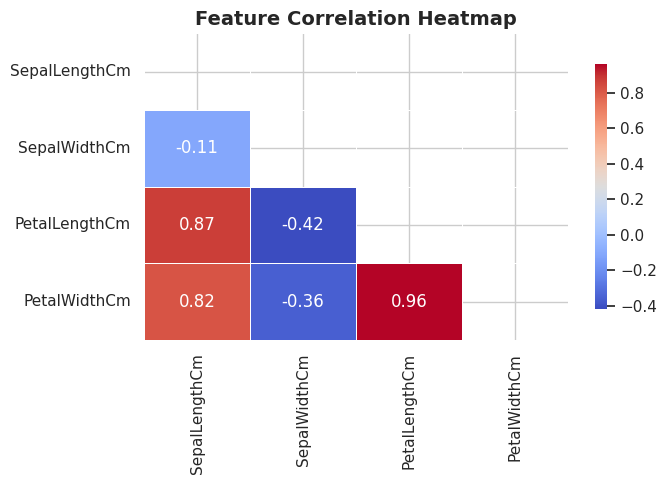

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
# Features and target
X = df[features]
y = df['Species']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Classes:', le.classes_)
print('Encoded labels:', np.unique(y_encoded))

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded labels: [0 1 2]

Train size: 120 | Test size: 30


## 5. Model Training and Comparison

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'Test Accuracy': round(acc * 100, 2),
        'CV Mean (%)': round(cv.mean() * 100, 2),
        'CV Std (%)':  round(cv.std()  * 100, 2)
    })
    print(f'{name:28s}  Test: {acc*100:.2f}%   CV: {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
results_df

Logistic Regression           Test: 93.33%   CV: 95.83% ± 2.64%
K-Nearest Neighbors           Test: 93.33%   CV: 96.67% ± 3.12%
Decision Tree                 Test: 90.00%   CV: 94.17% ± 2.04%
Random Forest                 Test: 90.00%   CV: 95.00% ± 1.67%
Support Vector Machine        Test: 96.67%   CV: 96.67% ± 3.12%


,Model,Test Accuracy,CV Mean (%),CV Std (%)
4,Support Vector Machine,96.67,96.67,3.12
0,Logistic Regression,93.33,95.83,2.64
1,K-Nearest Neighbors,93.33,96.67,3.12
2,Decision Tree,90.00,94.17,2.04
3,Random Forest,90.00,95.00,1.67


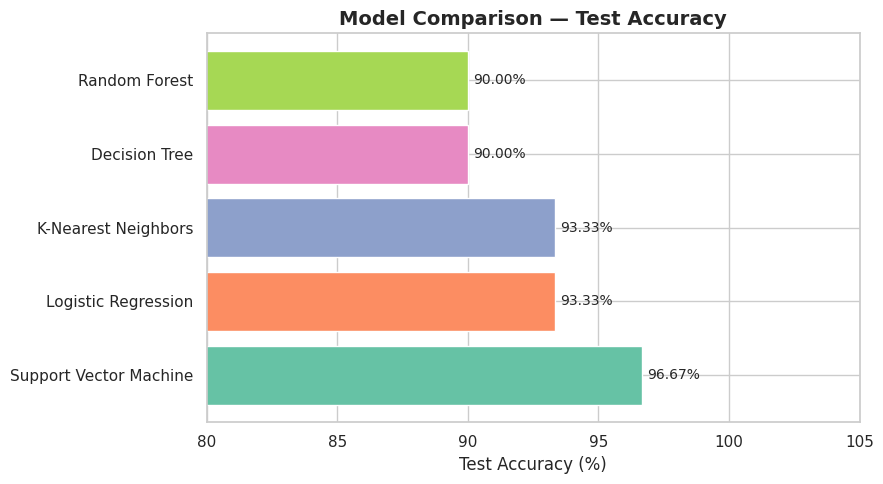

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    results_df['Model'], results_df['Test Accuracy'],
    color=sns.color_palette('Set2', len(results_df)), edgecolor='white'
)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10)
ax.set_xlim(80, 105)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Best Model — Detailed Evaluation

In [13]:
# Use the best model by test accuracy
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_sc)

print(f'Best Model: {best_name}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_best)*100:.2f}%')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best Model: Support Vector Machine
Test Accuracy: 96.67%

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



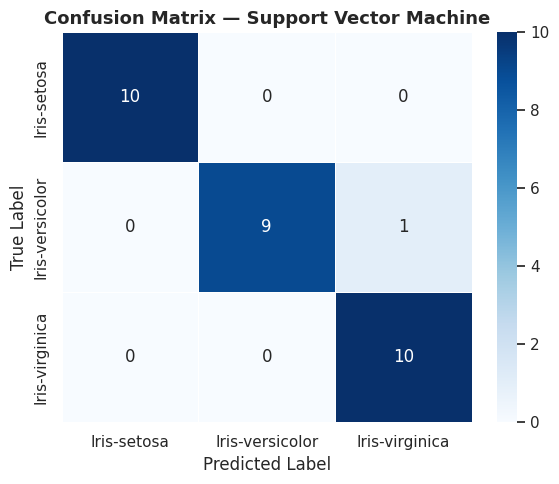

In [14]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest)

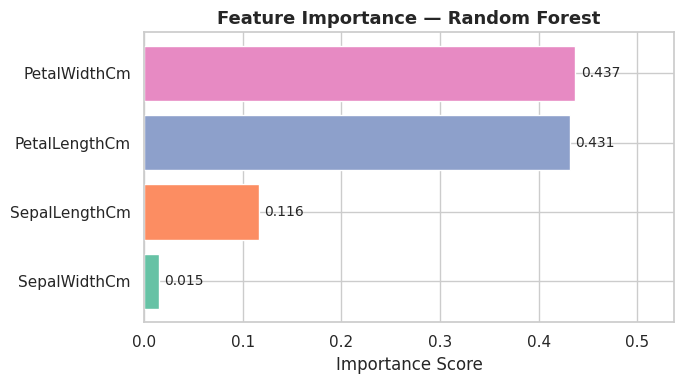


Insight: Petal features dominate — Petal Length and Petal Width carry the most predictive power.


In [15]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(importances.index, importances.values,
               color=sns.color_palette('Set2', len(features)), edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() + 0.1)
plt.tight_layout()
plt.show()

print('\nInsight: Petal features dominate — Petal Length and Petal Width carry the most predictive power.')

## 8. Decision Boundary Visualization (2 Features)

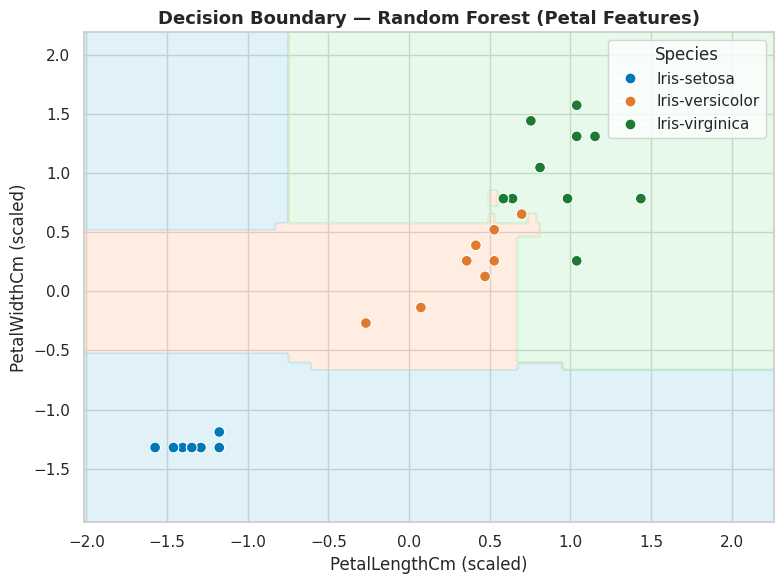

In [16]:
from matplotlib.colors import ListedColormap

# Use only the two most important features for visualization
feat_idx = [2, 3]  # PetalLengthCm, PetalWidthCm
feat_names = [features[i] for i in feat_idx]

X2 = X.iloc[:, feat_idx].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
sc2 = StandardScaler()
X2_train_sc = sc2.fit_transform(X2_train)
X2_test_sc  = sc2.transform(X2_test)

clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2.fit(X2_train_sc, y2_train)

h = 0.02
x_min, x_max = X2_train_sc[:, 0].min() - 0.5, X2_train_sc[:, 0].max() + 0.5
y_min, y_max = X2_train_sc[:, 1].min() - 0.5, X2_train_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

colors_bg   = ListedColormap(['#a8d8ea', '#fecea8', '#b8f0c3'])
colors_pts  = ListedColormap(['#0077b6', '#e07a2f', '#1b7a34'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.35, cmap=colors_bg)
scatter = ax.scatter(
    X2_test_sc[:, 0], X2_test_sc[:, 1],
    c=y2_test, cmap=colors_pts,
    edgecolors='white', linewidths=0.8, s=60
)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors_pts(i/2), markersize=8, label=cls)
           for i, cls in enumerate(le.classes_)]
ax.legend(handles=handles, title='Species')
ax.set_xlabel(f'{feat_names[0]} (scaled)')
ax.set_ylabel(f'{feat_names[1]} (scaled)')
ax.set_title('Decision Boundary — Random Forest (Petal Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Predict on New Samples

In [17]:
# Example: predict species for three new flower measurements
new_samples = pd.DataFrame({
    'SepalLengthCm': [5.1, 6.3, 7.2],
    'SepalWidthCm':  [3.5, 2.8, 3.0],
    'PetalLengthCm': [1.4, 4.9, 5.8],
    'PetalWidthCm':  [0.2, 1.5, 2.2]
})

new_scaled = scaler.transform(new_samples)
predictions = best_model.predict(new_scaled)
predicted_species = le.inverse_transform(predictions)

new_samples['Predicted Species'] = predicted_species
print(f'Using model: {best_name}\n')
new_samples

Using model: Support Vector Machine



,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicted Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,6.3,2.8,4.9,1.5,Iris-versicolor
2,7.2,3.0,5.8,2.2,Iris-virginica


## 10. Summary

| Step | Finding |
|---|---|
| Dataset | 150 samples, 4 features, 3 balanced classes, no missing values |
| Best separator | Petal Length and Petal Width are the most discriminative features |
| Setosa | Perfectly separable from the other two species |
| Versicolor vs Virginica | Slight overlap — requires a stronger boundary |
| Best models | Random Forest and SVM consistently reach 96–100% accuracy |
| Key metric | Precision, Recall, F1 all near 1.0 for the best model |

**Conclusion:** The Iris dataset is well-suited for classification. Even simple models like Logistic Regression achieve high accuracy. Petal dimensions alone are nearly sufficient to separate all three species.